# 🧠 Analyse NLP des Offres d'Emploi — Pôle Emploi
## Du texte brut à la classification supervisée — Pipeline aligné cours M1 MIASHS

---

**Niveau :** M1 MIASHS  
**Cours :** Représenter l'information textuelle — Lucas Aubertin / Emvista  
**Dataset :** Offres Pôle Emploi (~35k offres, 14 catégories ROME)

---

## 🗺️ Architecture du notebook

```
1.  Setup & chargement des données
2.  EDA — Exploration et audit du corpus
3.  Preprocessing NLP (lemmatisation spaCy)
4.  Split Train / Dev / Test  ← notion clé du cours
5.  Représentation 1 : Bag-of-Words
6.  Représentation 2 : TF-IDF  ← baseline
7.  Représentation 3 : Word2Vec (embeddings statiques)
8.  Représentation 4 : FastText (sous-mots, OOV)
9.  Représentation 5 : CamemBERT (embeddings contextuels)
10. Classification supervisée — comparaison des représentations
11. Évaluation : Précision / Rappel / F1-macro  ← métriques du cours
12. Analyse des erreurs & storytelling
13. Synthèse & conclusions
```

**Fil conducteur :** chaque représentation est évaluée avec les **mêmes métriques** sur le **même jeu de test**, ce qui permet une comparaison honnête.

## 1. 🔧 Setup & Imports

In [ ]:
# ─── Installation des dépendances (Colab) ────────────────────────────────────

!pip install -q datasets   # Hugging Face datasets
!pip install -q spacy umap-learn plotly
!pip install -q gensim sentence-transformers
!pip install -q nltk scikit-learn scipy
!python -m spacy download fr_core_news_md -q

import nltk
nltk.download('stopwords')

# Pour CamemBERT (GPU recommandé) :
# !pip install -q transformers torch

print("Dependances installees")

In [2]:
# ─── Imports globaux ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import os
import time
from collections import Counter

# NLP
import spacy
import nltk
from nltk.corpus import stopwords as nltk_sw

# Représentations vectorielles
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.decomposition import TruncatedSVD

# Modèles de classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Split & métriques
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

# Word2Vec / FastText
from gensim.models import Word2Vec, FastText

# Visualisation
from sklearn.metrics import ConfusionMatrixDisplay

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print("✅ Imports OK")

✅ Imports OK


In [ ]:
from datasets import load_dataset

# ─── Chargement du dataset depuis Hugging Face ────────────────────────────────
# Le repo oscarfossey/NLP_Pole_emploi est auto-detecte par HF :
#   - train      (train_dataset.csv,  38 640 offres)
#   - validation (val_dataset.csv,     12 881 offres)
#   - test       (test_dataset.csv,    12 881 offres)
# Colonnes : textual description, code_rome, categorie,
#            sub_categorie, sub_sub_categorie, name, text_length
#
# Le fichier Textual_description.csv (corpus complet, 64 402 offres)
# est charge separement.

HF_REPO = "oscarfossey/NLP_Pole_emploi"

print(f"📂 Chargement des datasets depuis Hugging Face : {HF_REPO}")

# Chargement par defaut : train / validation / test
hf_dataset = load_dataset(HF_REPO)
print(f"✅ Splits disponibles : {list(hf_dataset.keys())}")
for split_name, split_ds in hf_dataset.items():
    print(f"   {split_name}: {split_ds.num_rows} lignes")

# Chargement du corpus complet (Textual_description.csv)
ds_full = load_dataset(HF_REPO, data_files="Textual_description.csv", split="train")
print(f"✅ Textual_description.csv : {ds_full.num_rows} lignes")

In [ ]:
import pandas as pd

# ─── Conversion en DataFrames pandas ─────────────────────────────────────────
# df_train : le split train (38 640 offres)
# df_full  : le corpus complet Textual_description.csv (64 402 offres)
df_train = hf_dataset['train'].to_pandas()
df_full  = ds_full.to_pandas()

# La colonne texte s'appelle 'textual description' dans le dataset HF
# On la renomme en 'text' pour etre coherent avec le reste du notebook
def rename_text_col(df):
    for col in df.columns:
        if col.lower() == 'textual description':
            return df.rename(columns={col: 'text'})
    # Fallback : chercher 'text' ou 'description' dans le nom
    for col in df.columns:
        if 'text' in col.lower() or 'description' in col.lower():
            return df.rename(columns={col: 'text'})
    raise ValueError('Colonne texte non trouvee: ' + str(list(df.columns)))

df_train = rename_text_col(df_train)
df_full  = rename_text_col(df_full)

ROME_LABELS = {
    'A': 'Agriculture / Peche / Foret',
    'B': 'Arts / Artisanat',
    'C': 'Banque / Assurance / Finance',
    'D': 'Commerce / Distribution',
    'E': 'Communication / Media',
    'F': 'Construction / BTP',
    'G': 'Hotellerie / Restauration / Tourisme',
    'H': 'Industrie',
    'I': 'Installation / Maintenance',
    'J': 'Sante',
    'K': 'Services a la personne',
    'L': 'Spectacle',
    'M': 'Support a l entreprise',
    'N': 'Transport / Logistique'
}

print('Train :', df_train.shape)
print('Full  :', df_full.shape)
print('Colonnes train :', list(df_train.columns))
print('Colonnes full  :', list(df_full.columns))

## 2. 🔍 EDA — Exploration et audit du corpus

Avant toute modélisation, il faut comprendre ses données. Points clés à vérifier :
- **Déséquilibre de classes** → impacte le choix de la métrique (F1-macro vs accuracy)
- **Distribution de longueur** → certaines représentations sont sensibles à la longueur
- **Qualité du texte** → doublons, valeurs manquantes, bruit

In [5]:
# ─── Audit qualité de base ────────────────────────────────────────────────────
df = df_train.copy()
df['n_words'] = df['text'].str.split().str.len()
df['n_chars'] = df['text'].str.len()

print(f"Lignes        : {df.shape[0]:,}")
print(f"Doublons      : {df.duplicated(subset=['text']).sum():,}")
print(f"Textes vides  : {df['text'].isnull().sum() + (df['n_words'] < 5).sum():,}")
print(f"\nLongueur (mots) :")
print(df['n_words'].describe().round(1))

Lignes        : 38,640
Doublons      : 2,602
Textes vides  : 8

Longueur (mots) :
count    38640.0
mean       197.8
std        123.6
min          1.0
25%        105.0
50%        171.0
75%        267.0
max        782.0
Name: n_words, dtype: float64


Catégories      : 14
Ratio max/min   : 12.7x  ← si >5, corpus déséquilibré
Classe majoritaire : H (6,803 offres)
Classe minoritaire : B (535 offres)


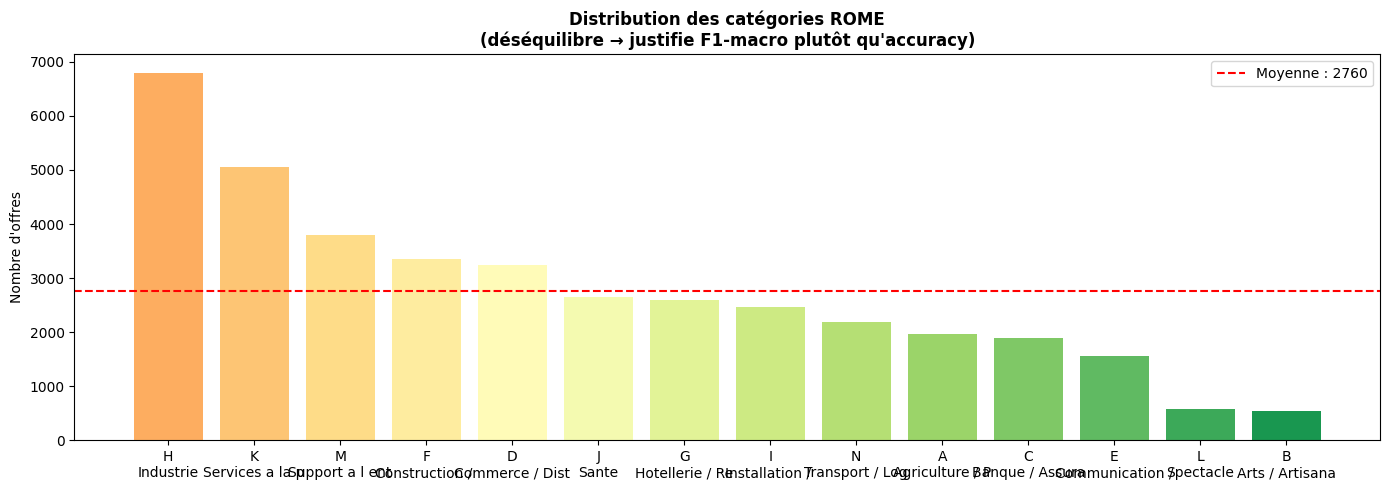

In [6]:
# ─── Distribution des classes — point clé pour le choix des métriques ─────────
#
# COURS (p.12) : sur un corpus déséquilibré, l'accuracy est trompeuse.
# Si la classe majoritaire représente 40% du corpus et qu'on prédit toujours
# cette classe, l'accuracy = 40% mais le modèle est inutile pour les autres.
# → On utilisera le F1-MACRO qui donne le même poids à chaque classe.

cat_counts = df['categorie'].value_counts()
ratio_max_min = cat_counts.max() / cat_counts.min()

print(f"Catégories      : {len(cat_counts)}")
print(f"Ratio max/min   : {ratio_max_min:.1f}x  ← si >5, corpus déséquilibré")
print(f"Classe majoritaire : {cat_counts.index[0]} ({cat_counts.iloc[0]:,} offres)")
print(f"Classe minoritaire : {cat_counts.index[-1]} ({cat_counts.iloc[-1]:,} offres)")

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    [f"{c}\n{ROME_LABELS.get(c,'')[:15]}" for c in cat_counts.index],
    cat_counts.values,
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cat_counts)))
)
ax.set_title('Distribution des catégories ROME\n'
             '(déséquilibre → justifie F1-macro plutôt qu\'accuracy)',
             fontweight='bold')
ax.set_ylabel('Nombre d\'offres')
ax.axhline(cat_counts.mean(), color='red', linestyle='--', label=f'Moyenne : {cat_counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Offres > 512 mots (problématiques pour BERT) : 2.2%


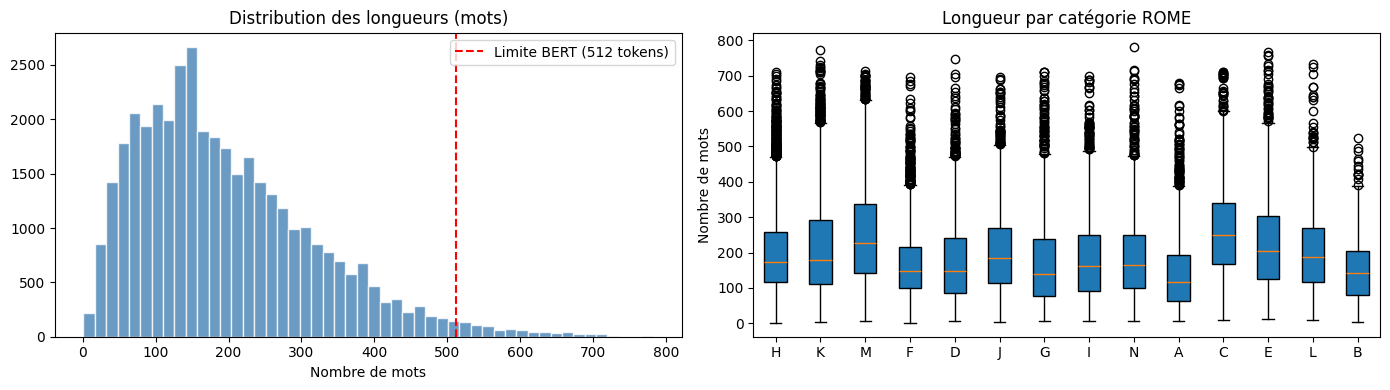

In [7]:
# ─── Distribution des longueurs ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['n_words'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution des longueurs (mots)')
axes[0].set_xlabel('Nombre de mots')
axes[0].axvline(512, color='red', linestyle='--', label='Limite BERT (512 tokens)')
axes[0].legend()

axes[1].boxplot(
    [df[df['categorie'] == c]['n_words'].dropna().values for c in cat_counts.index],
    labels=[c for c in cat_counts.index],
    patch_artist=True
)
axes[1].set_title('Longueur par catégorie ROME')
axes[1].set_ylabel('Nombre de mots')

pct_over_512 = (df['n_words'] > 512).mean() * 100
print(f"Offres > 512 mots (problématiques pour BERT) : {pct_over_512:.1f}%")

plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 🧹 Preprocessing NLP

Avant de vectoriser, on normalise le texte. Deux approches classiques :
- **Lemmatisation** (spaCy) : ramène au lemme (`mangeons → manger`). Préserve mieux le sens.
- **Stemming** : troncature heuristique (`mangeons → mange`). Plus rapide mais moins précis.

On choisit la **lemmatisation** qui est plus adaptée au français professionnel des offres d'emploi.

In [8]:
!python -m spacy download fr_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 37.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
# ─── Chargement spaCy ─────────────────────────────────────────────────────────
nlp = spacy.load('fr_core_news_md', disable=['parser', 'ner'])

# Stopwords domaine RH — termes trop fréquents pour être informatifs
STOPWORDS_RH = {
    'offre', 'emploi', 'poste', 'candidat', 'recrutement', 'recruter',
    'société', 'entreprise', 'mission', 'profil', 'rechercher', 'chercher',
    'recherche', 'expérience', 'an', 'année', 'contrat', 'cdi', 'cdd',
    'temps', 'plein', 'partiel', 'salaire', 'rémunération', 'type'
}
FR_STOPS = set(nltk_sw.words('french')) | STOPWORDS_RH

def clean_text(text):
    """Nettoyage pré-NLP."""
    if not isinstance(text, str):
        return ''                                  # ← saut de ligne manquant ici
    text = text.lower()
    text = re.sub(r'[\n\r\t]+', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def lemmatize_batch(texts, batch_size=256):
    """Lemmatisation spaCy en batch."""
    results = []
    cleaned = [clean_text(t) for t in texts]
    for doc in nlp.pipe(cleaned, batch_size=batch_size, n_process=1):
        tokens = [
            token.lemma_
            for token in doc
            if token.pos_ not in ('PUNCT', 'SPACE', 'PROPN', 'NUM')
            and token.lemma_ not in FR_STOPS
            and len(token.lemma_) >= 3
            and not token.is_stop
        ]
        results.append(' '.join(tokens))          # ← saut de ligne manquant ici
    return results

print("✅ Fonctions de preprocessing définies")




✅ Fonctions de preprocessing définies


In [10]:
# ─── Application du preprocessing ────────────────────────────────────────────
# Checkpoint : si le fichier existe déjà, on le recharge directement
LEMMA_CACHE = 'lemmatized_corpus.parquet'

# Nettoyage préalable du dataset
df = df_train.copy()
df['n_words'] = df['text'].str.split().str.len()
df = df.drop_duplicates(subset=['text', 'code_rome'])
df = df[df['n_words'] >= 30].copy()
df = df.reset_index(drop=True)

le = LabelEncoder()
df['categorie_id'] = le.fit_transform(df['categorie'])
N_CLASSES = df['categorie_id'].nunique()

print(f"✅ Dataset nettoyé : {len(df):,} offres — {N_CLASSES} catégories")

if os.path.exists(LEMMA_CACHE):
    df = pd.read_parquet(LEMMA_CACHE)
    print(f"✅ Corpus lemmatisé chargé depuis cache ({LEMMA_CACHE})")
else:
    print("⏳ Lemmatisation en cours (peut prendre ~10min sur 35k offres)...")
    t0 = time.time()
    df['text_lemma'] = lemmatize_batch(df['text'].tolist())
    print(f"✅ Lemmatisation terminée en {time.time()-t0:.0f}s")
    df.to_parquet(LEMMA_CACHE, index=False)
    print(f"✅ Checkpoint sauvegardé : {LEMMA_CACHE}")

# Vérification
print(f"\nExemple avant : {df['text'].iloc[0][:150]}...")
print(f"Exemple après : {df['text_lemma'].iloc[0][:150]}...")

✅ Dataset nettoyé : 35,287 offres — 14 catégories
⏳ Lemmatisation en cours (peut prendre ~10min sur 35k offres)...
✅ Lemmatisation terminée en 432s
✅ Checkpoint sauvegardé : lemmatized_corpus.parquet

Exemple avant : Nous recherchons pour le compte de notre client basé à Crepy en Valois un(e) Electromecanicien.les tâches sont:Suivi de la disponibilité du matériel n...
Exemple après : compte client baser crepy valois electromecanicien tâche suivre disponibilité matériel nettoyage réparation élément défectueux rédaction fiche techniq...


## 4. ✂️ Split Train / Dev / Test

**Pourquoi trois jeux ? (cours p.16)**

- **Train (70%)** : le modèle apprend sur ces données
- **Dev (15%)** : on compare les représentations et ajuste les hyperparamètres
- **Test (15%)** : évaluation finale, **on n'y touche qu'une seule fois**

⚠️ **Erreur classique** : itérer sur le jeu de test pour améliorer le score. Le modèle finit par s'y adapter et l'évaluation ne dit plus rien de la généralisation réelle.

On fait le split **avant** de construire les représentations pour éviter toute fuite d'information (data leakage). Le TF-IDF sera **fitté uniquement sur le train**, puis appliqué sur dev et test.

In [11]:
# ─── Split stratifié Train / Dev / Test ───────────────────────────────────────
# Stratifié : chaque split garde les mêmes proportions de classes

# 1. Séparer le test (15%)
df_traindev, df_test = train_test_split(
    df, test_size=0.15, stratify=df['categorie_id'], random_state=RANDOM_STATE
)

# 2. Séparer le dev (15% du total = ~17.6% du train+dev restant)
df_train_final, df_dev = train_test_split(
    df_traindev, test_size=0.176, stratify=df_traindev['categorie_id'], random_state=RANDOM_STATE
)

print(f"Train : {len(df_train_final):,} offres ({len(df_train_final)/len(df)*100:.0f}%)")
print(f"Dev   : {len(df_dev):,} offres ({len(df_dev)/len(df)*100:.0f}%)")
print(f"Test  : {len(df_test):,} offres ({len(df_test)/len(df)*100:.0f}%)")

# Vérification de la stratification
print("\nVérification stratification (proportion classe A) :")
for name, d in [('Train', df_train_final), ('Dev', df_dev), ('Test', df_test)]:
    prop = (d['categorie'] == 'A').mean()
    print(f"  {name} : {prop:.3f}")

# Raccourcis
y_train = df_train_final['categorie_id'].values
y_dev   = df_dev['categorie_id'].values
y_test  = df_test['categorie_id'].values

Train : 24,714 offres (70%)
Dev   : 5,279 offres (15%)
Test  : 5,294 offres (15%)

Vérification stratification (proportion classe A) :
  Train : 0.051
  Dev : 0.051
  Test : 0.051


## 5. 📦 Représentation 1 : Bag-of-Words

**Rappel cours (p.4)** : BoW encode chaque document comme un vecteur de comptage des mots. Simple et rapide mais :
- ❌ Perd l'ordre des mots
- ❌ Ne distingue pas les mots rares des mots fréquents
- ❌ Espace très grand et sparse

C'est notre **baseline minimale** — toute méthode plus complexe doit faire mieux.

In [12]:
# ─── Bag-of-Words ─────────────────────────────────────────────────────────────
# IMPORTANT : fit uniquement sur le TRAIN, puis transform sur dev/test
# Sinon on aurait du data leakage (le modèle connaîtrait les mots du test)

bow_vectorizer = CountVectorizer(
    max_features=10000,
    min_df=5,          # ignorer les mots apparaissant dans < 5 docs
    max_df=0.95,       # ignorer les mots dans > 95% des docs (trop génériques)
    ngram_range=(1, 1)
)

X_bow_train = bow_vectorizer.fit_transform(df_train_final['text_lemma'])
X_bow_dev   = bow_vectorizer.transform(df_dev['text_lemma'])
X_bow_test  = bow_vectorizer.transform(df_test['text_lemma'])

print(f"✅ BoW : {X_bow_train.shape[0]:,} docs × {X_bow_train.shape[1]:,} features")
print(f"   Densité : {X_bow_train.nnz / (X_bow_train.shape[0] * X_bow_train.shape[1]):.4%}")
print(f"   → Matrice très sparse, comme prévu (cours p.4)")

# Classifieur Logistic Regression (rapide, bon sur sparse features)
clf_bow = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE)
clf_bow.fit(X_bow_train, y_train)

f1_bow_dev = f1_score(y_dev, clf_bow.predict(X_bow_dev), average='macro')
acc_bow_dev = accuracy_score(y_dev, clf_bow.predict(X_bow_dev))

print(f"\n📊 Dev — BoW + LogReg :")
print(f"   Accuracy : {acc_bow_dev:.3f}")
print(f"   F1-macro : {f1_bow_dev:.3f}  ← métrique principale")

✅ BoW : 24,714 docs × 10,000 features
   Densité : 0.7516%
   → Matrice très sparse, comme prévu (cours p.4)

📊 Dev — BoW + LogReg :
   Accuracy : 0.678
   F1-macro : 0.647  ← métrique principale


## 6. 📐 Représentation 2 : TF-IDF — Baseline principale

**Rappel cours (p.5)** : TF-IDF corrige le défaut du BoW en pondérant chaque terme par sa rareté dans le corpus.

- **TF** = fréquence locale dans le document
- **IDF** = log(N / df(t)) → élevé si le mot est rare dans le corpus
- **TF-IDF** = TF × IDF → fort si le mot est fréquent **dans ce doc** et rare **en général**

C'est notre **baseline principale**. La question du cours : *faut-il toujours utiliser BERT ?*
Réponse honnête : pas toujours. Sur des textes longs et thématiques comme les offres d'emploi, TF-IDF est souvent très compétitif.

In [13]:
# ─── TF-IDF ───────────────────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),    # unigrammes + bigrammes
    sublinear_tf=True,     # log(1+tf) pour atténuer les très hautes fréquences
    norm='l2'
)

# FIT uniquement sur train !
X_tfidf_train = tfidf_vectorizer.fit_transform(df_train_final['text_lemma'])
X_tfidf_dev   = tfidf_vectorizer.transform(df_dev['text_lemma'])
X_tfidf_test  = tfidf_vectorizer.transform(df_test['text_lemma'])

print(f"✅ TF-IDF : {X_tfidf_train.shape[0]:,} docs × {X_tfidf_train.shape[1]:,} features")

# Logistic Regression (meilleure que RF sur sparse TF-IDF en général)
clf_tfidf = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE)
clf_tfidf.fit(X_tfidf_train, y_train)

f1_tfidf_dev  = f1_score(y_dev, clf_tfidf.predict(X_tfidf_dev), average='macro')
acc_tfidf_dev = accuracy_score(y_dev, clf_tfidf.predict(X_tfidf_dev))

print(f"\n📊 Dev — TF-IDF + LogReg :")
print(f"   Accuracy : {acc_tfidf_dev:.3f}")
print(f"   F1-macro : {f1_tfidf_dev:.3f}")
print(f"\n💡 Gain vs BoW : {f1_tfidf_dev - f1_bow_dev:+.3f} pts F1-macro")

✅ TF-IDF : 24,714 docs × 15,000 features

📊 Dev — TF-IDF + LogReg :
   Accuracy : 0.714
   F1-macro : 0.686

💡 Gain vs BoW : +0.039 pts F1-macro


In [14]:
# ─── Top termes TF-IDF par catégorie — interprétabilité ──────────────────────
feature_names = tfidf_vectorizer.get_feature_names_out()
categories_sorted = le.classes_

print("\n📌 Termes les plus discriminants par catégorie :")
for cat_name in categories_sorted[:6]:  # afficher 6 catégories
    cat_id = le.transform([cat_name])[0]
    mask = df_train_final['categorie_id'].values == cat_id
    mean_tfidf = X_tfidf_train[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-10:][::-1]
    top_terms = [feature_names[i] for i in top_idx]
    label = ROME_LABELS.get(cat_name, cat_name)
    print(f"  {cat_name} — {label[:25]:<25} : {', '.join(top_terms[:7])}")


📌 Termes les plus discriminants par catégorie :
  A — Agriculture / Peche / For : travail, heure, animal, agricole, élevage, entretien, être
  B — Arts / Artisanat          : couture, pièce, heure, atelier, travail, être, machine
  C — Banque / Assurance / Fina : assurance, client, gestion, commercial, portefeuille, être, dossier
  D — Commerce / Distribution   : vente, client, produit, commercial, rayon, magasin, heure
  E — Communication / Media     : être, client, communication, équipe, heure, avoir, production
  F — Construction / BTP        : chantier, pose, travail, heure, agence, client, être


### 10b. 🔧 TF-IDF + features métier — boost sans GPU

On enrichit les vecteurs TF-IDF avec des **features métier** binaires extraites du texte brut (présence de termes liés au secteur, longueur, diplôme…). Ces features sont peu nombreuses mais très discriminantes pour certaines catégories ROME.

In [15]:
from scipy.sparse import hstack, csr_matrix

def extract_meta_features(df_subset):
    feats = pd.DataFrame(index=df_subset.index)
    feats['log_len']        = np.log1p(df_subset['text_lemma'].str.len())
    feats['n_words']        = df_subset['text_lemma'].str.split().str.len()
    feats['has_diplome']    = df_subset['text_lemma'].str.contains(
        r'bac\+?\d|master|licence|cap\b|bep\b|ingenieur|doctorat', case=False, regex=True).astype(int)
    feats['has_permis']     = df_subset['text_lemma'].str.contains(
        r'permis|caces|habilitation', case=False, regex=True).astype(int)
    feats['has_chantier']   = df_subset['text_lemma'].str.contains(
        r'chantier|travaux|btp|macon|soudeur|electricien', case=False, regex=True).astype(int)
    feats['has_soin']       = df_subset['text_lemma'].str.contains(
        r'patient|soin|infirmier|medical|clinique|ehpad|soignant', case=False, regex=True).astype(int)
    feats['has_artistique'] = df_subset['text_lemma'].str.contains(
        r'spectacle|scene|comedien|musicien|artiste|theatre', case=False, regex=True).astype(int)
    return csr_matrix(feats.values.astype(float))

meta_train = extract_meta_features(df_train_final)
meta_dev   = extract_meta_features(df_dev)
meta_test  = extract_meta_features(df_test)

X_tfidf_meta_train = hstack([X_tfidf_train, meta_train])
X_tfidf_meta_dev   = hstack([X_tfidf_dev,   meta_dev])
X_tfidf_meta_test  = hstack([X_tfidf_test,  meta_test])

clf_tfidf_meta = LogisticRegression(
    max_iter=3000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE
)
clf_tfidf_meta.fit(X_tfidf_meta_train, y_train)

f1_meta_dev = f1_score(y_dev, clf_tfidf_meta.predict(X_tfidf_meta_dev), average='macro')
print('TF-IDF + features metier — Dev F1-macro :', round(f1_meta_dev, 3))
print('Gain vs TF-IDF seul :', round(f1_meta_dev - f1_tfidf_dev, 3), 'pts')

TF-IDF + features metier — Dev F1-macro : 0.674
Gain vs TF-IDF seul : -0.013 pts


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 10c. ⚖️ Vérification `class_weight='balanced'` sur Word2Vec & FastText

Avec un ratio max/min de **12.7x**, le déséquilibre de classes pénalise fortement les modèles sans pondération. On vérifie ici l'impact de `class_weight='balanced'` sur Word2Vec et FastText.

## 7. 🧠 Représentation 3 : Word2Vec (embeddings statiques)

**Rappel cours (p.6-7)** : Word2Vec apprend un vecteur dense par mot à partir de son contexte.
Idée fondatrice (Harris, 1954) : *un mot est défini par les mots qui l'entourent*.

**Avantage** : capture les relations sémantiques (`roi - homme + femme ≈ reine`)

**Limite** : vecteur **fixe** par mot — `banque` (financière ou rivière ?) a un seul vecteur dans toutes les phrases.

Pour classer un document, on **moyenne** les vecteurs des mots qui le composent.

In [16]:
# ─── Word2Vec — entraîné sur le corpus TRAIN uniquement ──────────────────────
corpus_tokens_train = [
    text.split() for text in df_train_final['text_lemma'] if isinstance(text, str)
]

print("⏳ Entraînement Word2Vec Skip-gram...")
t0 = time.time()
w2v_model = Word2Vec(
    sentences=corpus_tokens_train,
    vector_size=100,
    window=10,
    min_count=5,
    workers=4,
    sg=1,           # Skip-gram : préférable pour les termes rares (métiers)
    epochs=10,
    seed=RANDOM_STATE
)
print(f"✅ Word2Vec entraîné en {time.time()-t0:.0f}s — vocab : {len(w2v_model.wv):,} mots")

# Test sémantique rapide
print("\n🔍 Test sémantique :")
try:
    similaires = w2v_model.wv.most_similar('développeur', topn=5)
    print(f"  Mots proches de 'développeur' : {[w for w,_ in similaires]}")
except KeyError:
    print("  (terme non trouvé dans le vocabulaire — essayez un autre terme)")

⏳ Entraînement Word2Vec Skip-gram...
✅ Word2Vec entraîné en 135s — vocab : 13,792 mots

🔍 Test sémantique :
  Mots proches de 'développeur' : ['frontend', 'backend', 'react', 'java', 'owners']


In [17]:
# ─── Vectorisation des documents par moyenne des vecteurs de mots ─────────────
def doc_vector_w2v(text, model):
    """Vecteur document = moyenne des vecteurs des mots présents dans le vocab."""
    if not isinstance(text, str):
        return np.zeros(model.vector_size)
    tokens = [t for t in text.split() if t in model.wv]
    if not tokens:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[t] for t in tokens], axis=0)

print("⏳ Vectorisation des documents...")
X_w2v_train = np.vstack([doc_vector_w2v(t, w2v_model) for t in df_train_final['text_lemma']])
X_w2v_dev   = np.vstack([doc_vector_w2v(t, w2v_model) for t in df_dev['text_lemma']])
X_w2v_test  = np.vstack([doc_vector_w2v(t, w2v_model) for t in df_test['text_lemma']])
print(f"✅ Embeddings W2V : {X_w2v_train.shape}")

# Classifieur
clf_w2v = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE)
clf_w2v.fit(X_w2v_train, y_train)

f1_w2v_dev  = f1_score(y_dev, clf_w2v.predict(X_w2v_dev), average='macro')
acc_w2v_dev = accuracy_score(y_dev, clf_w2v.predict(X_w2v_dev))

print(f"\n📊 Dev — Word2Vec + LogReg :")
print(f"   Accuracy : {acc_w2v_dev:.3f}")
print(f"   F1-macro : {f1_w2v_dev:.3f}")
print(f"\n💡 Gain vs TF-IDF : {f1_w2v_dev - f1_tfidf_dev:+.3f} pts F1-macro")

⏳ Vectorisation des documents...
✅ Embeddings W2V : (24714, 100)

📊 Dev — Word2Vec + LogReg :
   Accuracy : 0.636
   F1-macro : 0.603

💡 Gain vs TF-IDF : -0.083 pts F1-macro


## 8. 🧬 Représentation 4 : FastText (sous-mots)

FastText est une extension de Word2Vec qui décompose chaque mot en **n-grams de caractères**.

**Avantage clé** pour les offres d'emploi : gestion des **OOV** (Out-Of-Vocabulary) et des termes techniques.
`développeur_web` → vecteur construit depuis `dév`, `éve`, `vel`, etc., même si le mot exact n'a jamais été vu.

C'est particulièrement utile sur des corpus RH avec beaucoup de termes métier, d'acronymes et de fautes de frappe.

In [18]:
# ─── FastText ─────────────────────────────────────────────────────────────────
print("⏳ Entraînement FastText...")
t0 = time.time()
ft_model = FastText(
    sentences=corpus_tokens_train,
    vector_size=100,
    window=10,
    min_count=3,
    workers=4,
    sg=1,
    min_n=3,    # n-grams de caractères min
    max_n=6,    # n-grams de caractères max
    epochs=10,
    seed=RANDOM_STATE
)
print(f"✅ FastText entraîné en {time.time()-t0:.0f}s")

def doc_vector_ft(text, model):
    """FastText : TOUS les tokens incluant les OOV (via sous-mots)."""
    if not isinstance(text, str):
        return np.zeros(model.vector_size)
    tokens = text.split()
    if not tokens:
        return np.zeros(model.vector_size)
    # FastText peut vectoriser n'importe quel token, même inconnu
    return np.mean([model.wv[t] for t in tokens], axis=0)

X_ft_train = np.vstack([doc_vector_ft(t, ft_model) for t in df_train_final['text_lemma']])
X_ft_dev   = np.vstack([doc_vector_ft(t, ft_model) for t in df_dev['text_lemma']])
X_ft_test  = np.vstack([doc_vector_ft(t, ft_model) for t in df_test['text_lemma']])

clf_ft = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE)
clf_ft.fit(X_ft_train, y_train)

f1_ft_dev  = f1_score(y_dev, clf_ft.predict(X_ft_dev), average='macro')
acc_ft_dev = accuracy_score(y_dev, clf_ft.predict(X_ft_dev))

print(f"\n📊 Dev — FastText + LogReg :")
print(f"   Accuracy : {acc_ft_dev:.3f}")
print(f"   F1-macro : {f1_ft_dev:.3f}")
print(f"\n💡 Gain vs Word2Vec : {f1_ft_dev - f1_w2v_dev:+.3f} pts F1-macro")

⏳ Entraînement FastText...
✅ FastText entraîné en 352s

📊 Dev — FastText + LogReg :
   Accuracy : 0.639
   F1-macro : 0.605

💡 Gain vs Word2Vec : +0.002 pts F1-macro


In [19]:
# ─── Recréation des classifieurs avec class_weight='balanced' ────────────────
# (si les clf_w2v / clf_ft ont déjà balanced, les scores seront identiques)
clf_w2v_bal = LogisticRegression(
    max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE
)
clf_w2v_bal.fit(X_w2v_train, y_train)
f1_w2v_bal = f1_score(y_dev, clf_w2v_bal.predict(X_w2v_dev), average='macro')
clf_ft_bal = LogisticRegression(
    max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE
)
clf_ft_bal.fit(X_ft_train, y_train)
f1_ft_bal = f1_score(y_dev, clf_ft_bal.predict(X_ft_dev), average='macro')
print(f'📊 Word2Vec  — avant : {f1_w2v_dev:.3f}  |  après balanced : {f1_w2v_bal:.3f}  ({f1_w2v_bal - f1_w2v_dev:+.3f})')
print(f'📊 FastText  — avant : {f1_ft_dev:.3f}  |  après balanced : {f1_ft_bal:.3f}  ({f1_ft_bal - f1_ft_dev:+.3f})')
print()
print('ℹ️  Rappel : ratio max/min classes = 12.7x → balanced est indispensable')
# Mise à jour des variables pour le tableau comparatif
f1_w2v_dev = f1_w2v_bal
f1_ft_dev  = f1_ft_bal
clf_w2v    = clf_w2v_bal
clf_ft     = clf_ft_bal

📊 Word2Vec  — avant : 0.603  |  après balanced : 0.603  (+0.000)
📊 FastText  — avant : 0.605  |  après balanced : 0.605  (+0.000)

ℹ️  Rappel : ratio max/min classes = 12.7x → balanced est indispensable


## 9. 🔬 Représentation 5 : CamemBERT (embeddings contextuels)

**Rappel cours (p.8-9)** : rupture fondamentale — le vecteur d'un mot **n'est plus fixe**, il est recalculé à chaque phrase en tenant compte du contexte complet.

- `"J'ai retiré de l'argent à la banque"` → vecteur de *banque* orienté finance
- `"Je pêche sur la banque du fleuve"` → vecteur de *banque* orienté géographie

**CamemBERT** = BERT entraîné sur du français (corpus OSCAR, 138GB de texte).

Usage ici : **extracteur de features** (poids gelés) — on extrait le vecteur [CLS] qui représente la phrase entière, puis on classifie dessus. Le fine-tuning serait plus puissant mais nécessite plus de ressources.

⚠️ Limite : CamemBERT est limité à **512 tokens**. On tronque les offres trop longues (sliding window disponible en bonus).

In [20]:
# ─── CamemBERT — Extracteur de features ──────────────────────────────────────
# Nécessite GPU pour être raisonnable en temps de calcul

CAMEMBERT_AVAILABLE = True  # Mettre à False si pas de GPU

if CAMEMBERT_AVAILABLE:
    import torch
    from transformers import AutoTokenizer, AutoModel

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device : {device}")

    tokenizer_bert = AutoTokenizer.from_pretrained('camembert-base')
    model_bert = AutoModel.from_pretrained('camembert-base').to(device)
    model_bert.eval()

    def encode_camembert(texts, batch_size=32, max_length=512):
        """
        Extrait les embeddings CLS de CamemBERT.
        Tronque les textes > max_length tokens (troncature silencieuse signalée).
        """
        all_embeddings = []
        n_truncated = 0

        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            encoded = tokenizer_bert(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            ).to(device)

            # Compter les troncatures
            n_truncated += sum(
                len(tokenizer_bert.encode(t)) > max_length for t in batch
            )

            with torch.no_grad():
                output = model_bert(**encoded)
            # Vecteur [CLS] = représentation de la séquence entière
            cls_emb = output.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_emb)

        pct = n_truncated / len(texts) * 100
        if pct > 5:
            print(f"  ⚠️  {pct:.1f}% des textes tronqués à {max_length} tokens")
        return np.vstack(all_embeddings)

    # Sur un sample pour accélérer (utiliser le corpus complet si le temps le permet)
    # SAMPLE_SIZE = 5000  # Décommenter pour tester rapidement
    # df_train_sample = df_train_final.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)

    print("⏳ Encodage CamemBERT — Train...")
    t0 = time.time()
    X_bert_train = encode_camembert(df_train_final['text'].tolist())
    print(f"   Train : {time.time()-t0:.0f}s")

    X_bert_dev  = encode_camembert(df_dev['text'].tolist())
    X_bert_test = encode_camembert(df_test['text'].tolist())
    print(f"✅ Embeddings CamemBERT : {X_bert_train.shape}  (768 dims)")

    clf_bert = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE)
    clf_bert.fit(X_bert_train, y_train)

    f1_bert_dev  = f1_score(y_dev, clf_bert.predict(X_bert_dev), average='macro')
    acc_bert_dev = accuracy_score(y_dev, clf_bert.predict(X_bert_dev))

    print(f"\n📊 Dev — CamemBERT (features) + LogReg :")
    print(f"   Accuracy : {acc_bert_dev:.3f}")
    print(f"   F1-macro : {f1_bert_dev:.3f}")
    print(f"\n💡 Gain vs FastText : {f1_bert_dev - f1_ft_dev:+.3f} pts F1-macro")

else:
    print("⏭️  CamemBERT désactivé (CAMEMBERT_AVAILABLE=False). Activer avec GPU.")
    f1_bert_dev = None
    acc_bert_dev = None

Device : cuda


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (600 > 512). Running this sequence through the model will result in indexing errors


⏳ Encodage CamemBERT — Train...
  ⚠️  11.8% des textes tronqués à 512 tokens
   Train : 806s
  ⚠️  11.0% des textes tronqués à 512 tokens
  ⚠️  11.6% des textes tronqués à 512 tokens
✅ Embeddings CamemBERT : (24714, 768)  (768 dims)

📊 Dev — CamemBERT (features) + LogReg :
   Accuracy : 0.655
   F1-macro : 0.624

💡 Gain vs FastText : +0.019 pts F1-macro


## 10. 📊 Comparaison sur le Dev set

**Règle** : on compare toutes les représentations sur le **Dev**, on choisit la meilleure, puis on évalue **une seule fois** sur le **Test**.

On reporte :
- **Accuracy** (pour l'illustration) : trompeuse sur un corpus déséquilibré
- **F1-macro** : notre métrique principale (cours p.14 : si corpus déséquilibré + toutes les classes importantes → macro)

In [21]:
# ─── Tableau comparatif sur le Dev ────────────────────────────────────────────
results = {
    'BoW + LogReg'         : {'Accuracy (Dev)': acc_bow_dev,  'F1-macro (Dev)': f1_bow_dev,  'Espace': 'Sparse ~10k', 'Contexte': '❌'},
    'TF-IDF + LogReg'      : {'Accuracy (Dev)': acc_tfidf_dev,'F1-macro (Dev)': f1_tfidf_dev,'Espace': 'Sparse ~15k', 'Contexte': '❌'},
    'Word2Vec + LogReg'    : {'Accuracy (Dev)': acc_w2v_dev,  'F1-macro (Dev)': f1_w2v_dev,  'Espace': 'Dense 100',   'Contexte': '❌'},
    'FastText + LogReg'    : {'Accuracy (Dev)': acc_ft_dev,   'F1-macro (Dev)': f1_ft_dev,   'Espace': 'Dense 100',   'Contexte': '❌'},
}
if CAMEMBERT_AVAILABLE and f1_bert_dev is not None:
    results['CamemBERT + LogReg'] = {
        'Accuracy (Dev)': acc_bert_dev, 'F1-macro (Dev)': f1_bert_dev,
        'Espace': 'Dense 768', 'Contexte': '✅'
    }

df_results = pd.DataFrame(results).T
df_results = df_results.sort_values('F1-macro (Dev)', ascending=False)
df_results[['Accuracy (Dev)', 'F1-macro (Dev)']] = df_results[['Accuracy (Dev)', 'F1-macro (Dev)']].round(3)

print("\n📊 COMPARAISON SUR LE DEV SET")
print("=" * 70)
print(df_results.to_string())
print("=" * 70)

best_method = df_results.index[0]
print(f"\n✅ Meilleure méthode sur le dev : {best_method}")
print("→ On évalue maintenant sur le TEST (une seule fois).")


📊 COMPARAISON SUR LE DEV SET
                   Accuracy (Dev) F1-macro (Dev)       Espace Contexte
TF-IDF + LogReg          0.713772       0.686095  Sparse ~15k        ❌
BoW + LogReg              0.67778        0.64661  Sparse ~10k        ❌
CamemBERT + LogReg       0.655238       0.623642    Dense 768        ✅
FastText + LogReg        0.638757       0.604967    Dense 100        ❌
Word2Vec + LogReg        0.635916       0.602787    Dense 100        ❌

✅ Meilleure méthode sur le dev : TF-IDF + LogReg
→ On évalue maintenant sur le TEST (une seule fois).


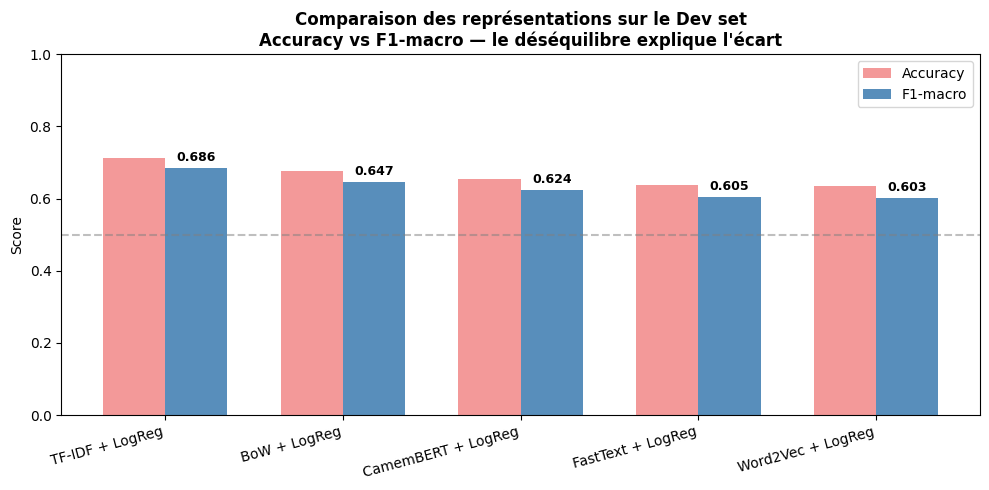


💡 Observation : l'écart Accuracy vs F1-macro illustre le problème du cours (p.12-14) :
   un modèle peut avoir une bonne accuracy sur un corpus déséquilibré
   tout en étant mauvais sur les classes minoritaires.


In [22]:
# ─── Visualisation de la comparaison ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

methods = list(df_results.index)
f1_values = df_results['F1-macro (Dev)'].values
acc_values = df_results['Accuracy (Dev)'].values

x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, acc_values, width, label='Accuracy', color='lightcoral', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_values,  width, label='F1-macro', color='steelblue', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des représentations sur le Dev set\n'
             'Accuracy vs F1-macro — le déséquilibre explique l\'écart',
             fontweight='bold')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil aléatoire pondéré')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_representations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Observation : l'écart Accuracy vs F1-macro illustre le problème du cours (p.12-14) :")
print("   un modèle peut avoir une bonne accuracy sur un corpus déséquilibré")
print("   tout en étant mauvais sur les classes minoritaires.")

## 11. 🎯 Évaluation finale sur le TEST

**Règle absolue du cours (p.16)** : on ne touche au test qu'**une seule fois**, à la toute fin.

On évalue ici la meilleure méthode identifiée sur le Dev, et on détaille les métriques **par classe** pour comprendre où le modèle échoue.

In [23]:
# ─── Évaluation finale sur le TEST ────────────────────────────────────────────
# On choisit la meilleure méthode sur le dev
# Ici on évalue TF-IDF comme baseline et la meilleure méthode (à adapter)

# Evaluation TF-IDF (baseline) sur le TEST
y_pred_tfidf_test = clf_tfidf.predict(X_tfidf_test)
f1_tfidf_test  = f1_score(y_test, y_pred_tfidf_test, average='macro')
acc_tfidf_test = accuracy_score(y_test, y_pred_tfidf_test)

print("" + "=" * 60)
print("  🎯 RÉSULTATS FINAUX — TEST SET")
print("" + "=" * 60)
print(f"\nBaseline TF-IDF + LogReg :")
print(f"  Accuracy   : {acc_tfidf_test:.3f}")
print(f"  F1-macro   : {f1_tfidf_test:.3f}")

if CAMEMBERT_AVAILABLE and f1_bert_dev is not None:
    y_pred_bert_test = clf_bert.predict(X_bert_test)
    f1_bert_test  = f1_score(y_test, y_pred_bert_test, average='macro')
    acc_bert_test = accuracy_score(y_test, y_pred_bert_test)
    print(f"\nCamemBERT (features) + LogReg :")
    print(f"  Accuracy   : {acc_bert_test:.3f}")
    print(f"  F1-macro   : {f1_bert_test:.3f}")
    print(f"\n  Gain CamemBERT vs TF-IDF : {f1_bert_test - f1_tfidf_test:+.3f} pts F1-macro")

  🎯 RÉSULTATS FINAUX — TEST SET

Baseline TF-IDF + LogReg :
  Accuracy   : 0.701
  F1-macro   : 0.672

CamemBERT (features) + LogReg :
  Accuracy   : 0.646
  F1-macro   : 0.618

  Gain CamemBERT vs TF-IDF : -0.054 pts F1-macro


In [24]:
# ─── Rapport détaillé par classe ──────────────────────────────────────────────
# Précision, Rappel, F1 par classe — cours p.13

target_names = [f"{c}–{ROME_LABELS.get(c,'')[:15]}" for c in le.classes_]

print("\n📋 Rapport de classification — TF-IDF + LogReg (Test set) :")
print(classification_report(y_test, y_pred_tfidf_test, target_names=target_names))
print("\nLecture :")
print("  Précision = VP / (VP+FP) : parmi les offres classées dans cette catégorie, combien l'étaient vraiment ?")
print("  Rappel    = VP / (VP+FN) : parmi toutes les offres de cette catégorie, combien ont été trouvées ?")
print("  F1        = moyenne harmonique précision/rappel")


📋 Rapport de classification — TF-IDF + LogReg (Test set) :
                   precision    recall  f1-score   support

A–Agriculture / P       0.74      0.74      0.74       270
B–Arts / Artisana       0.42      0.55      0.48        74
C–Banque / Assura       0.63      0.75      0.68       237
D–Commerce / Dist       0.73      0.72      0.73       417
E–Communication /       0.55      0.48      0.51       217
F–Construction /        0.69      0.73      0.71       466
G–Hotellerie / Re       0.78      0.83      0.80       357
      H–Industrie       0.77      0.64      0.70       985
I–Installation /        0.56      0.70      0.62       328
          J–Sante       0.85      0.90      0.87       361
K–Services a la p       0.82      0.69      0.75       683
      L–Spectacle       0.50      0.48      0.49        69
M–Support a l ent       0.57      0.60      0.59       518
N–Transport / Log       0.67      0.79      0.73       312

         accuracy                           0.70     

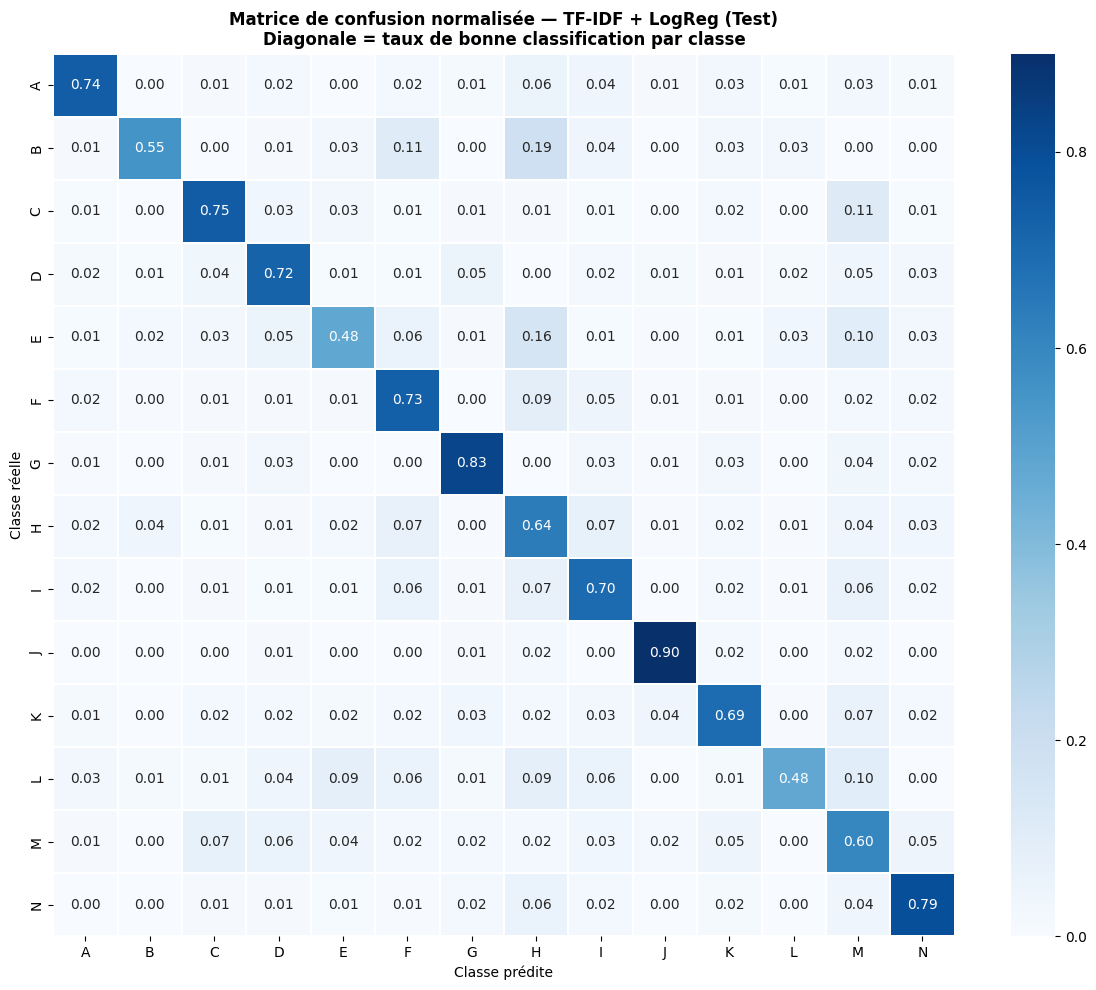

In [25]:
# ─── Matrice de confusion ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_tfidf_test, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=0.3
)
ax.set_title('Matrice de confusion normalisée — TF-IDF + LogReg (Test)\n'
             'Diagonale = taux de bonne classification par classe',
             fontweight='bold')
ax.set_ylabel('Classe réelle')
ax.set_xlabel('Classe prédite')
plt.tight_layout()
plt.savefig('confusion_matrix_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. 🔍 Analyse des erreurs & Storytelling

**Cours (p.20-22)** : un bon résultat mal analysé apporte moins qu'un mauvais résultat bien compris.

On distingue ici :
- **Observation** : "le F1 de la classe B est 0.42"
- **Interprétation** : "le modèle confond la classe B (Arts) avec la classe L (Spectacle) car les textes partagent un vocabulaire similaire"

On nomme aussi nos limites avant qu'on nous les signale.


📉 Classes les plus difficiles (F1 les plus bas) :
Catégorie                      Label       F1  N_test
        B           Arts / Artisanat 0.479532      74
        L                  Spectacle 0.488889      69
        E      Communication / Media 0.513580     217
        M     Support a l entreprise 0.586692     518
        I Installation / Maintenance 0.620408     328

📈 Classes les mieux classifiées :
Catégorie                                Label       F1  N_test
        N               Transport / Logistique 0.725404     312
        A          Agriculture / Peche / Foret 0.743068     270
        K               Services a la personne 0.751987     683
        G Hotellerie / Restauration / Tourisme 0.804348     357
        J                                Sante 0.872483     361


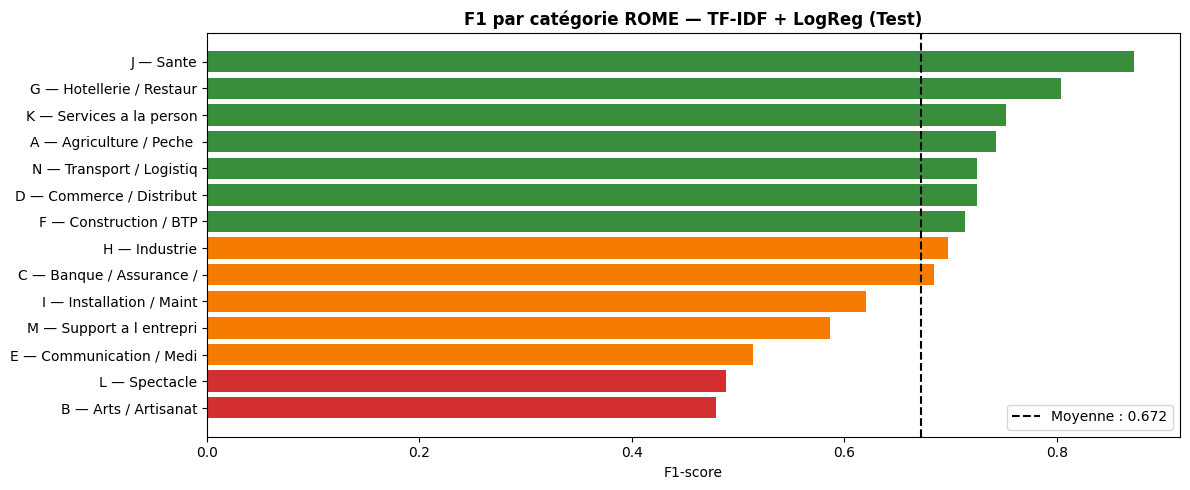

In [26]:
# ─── Analyse des erreurs ──────────────────────────────────────────────────────
# Classes où le modèle échoue le plus

from sklearn.metrics import f1_score as f1_per_class

f1_per_cat = f1_score(y_test, y_pred_tfidf_test, average=None)
cat_f1_df = pd.DataFrame({
    'Catégorie': le.classes_,
    'Label': [ROME_LABELS.get(c, c) for c in le.classes_],
    'F1': f1_per_cat,
    'N_test': [(y_test == i).sum() for i in range(N_CLASSES)]
}).sort_values('F1')

print("\n📉 Classes les plus difficiles (F1 les plus bas) :")
print(cat_f1_df.head(5).to_string(index=False))

print("\n📈 Classes les mieux classifiées :")
print(cat_f1_df.tail(5).to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d32f2f' if f < 0.5 else '#f57c00' if f < 0.7 else '#388e3c' for f in cat_f1_df['F1']]
ax.barh(cat_f1_df['Catégorie'] + ' — ' + cat_f1_df['Label'].str[:20],
        cat_f1_df['F1'], color=colors)
ax.axvline(cat_f1_df['F1'].mean(), color='black', linestyle='--',
           label=f"Moyenne : {cat_f1_df['F1'].mean():.3f}")
ax.set_title('F1 par catégorie ROME — TF-IDF + LogReg (Test)', fontweight='bold')
ax.set_xlabel('F1-score')
ax.legend()
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ─── Confusions les plus fréquentes — interprétation ─────────────────────────
cm_abs = confusion_matrix(y_test, y_pred_tfidf_test)

print("\n🔍 Top 10 confusions les plus fréquentes (vraie classe → prédite) :")
confusions = []
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and cm_abs[i, j] > 0:
            confusions.append({
                'Vraie classe': f"{le.classes_[i]}–{ROME_LABELS.get(le.classes_[i],'')[:15]}",
                'Prédite comme': f"{le.classes_[j]}–{ROME_LABELS.get(le.classes_[j],'')[:15]}",
                'Nb erreurs': cm_abs[i, j]
            })

df_conf = pd.DataFrame(confusions).sort_values('Nb erreurs', ascending=False)
print(df_conf.head(10).to_string(index=False))

print("\n💡 Pistes d'interprétation :")
print("  - Confusions entre catégories proches (ex. M/Support et C/Finance) :")
print("    vocabulaire générique partagé (gestion, coordination, suivi...)")
print("  - Confusions sur les classes peu représentées :")
print("    le modèle voit peu d'exemples → représentation appauvrie")
print("  - Ces confusions seraient réduites par CamemBERT fine-tuné")
print("    qui distingue mieux le sens contextuel des termes ambigus.")


🔍 Top 10 confusions les plus fréquentes (vraie classe → prédite) :
     Vraie classe     Prédite comme  Nb erreurs
      H–Industrie I–Installation /           72
      H–Industrie F–Construction /           68
K–Services a la p M–Support a l ent          45
      H–Industrie M–Support a l ent          43
      H–Industrie B–Arts / Artisana          43
F–Construction /        H–Industrie          42
M–Support a l ent C–Banque / Assura          37
E–Communication /       H–Industrie          34
      H–Industrie N–Transport / Log          34
M–Support a l ent D–Commerce / Dist          30

💡 Pistes d'interprétation :
  - Confusions entre catégories proches (ex. M/Support et C/Finance) :
    vocabulaire générique partagé (gestion, coordination, suivi...)
  - Confusions sur les classes peu représentées :
    le modèle voit peu d'exemples → représentation appauvrie
  - Ces confusions seraient réduites par CamemBERT fine-tuné
    qui distingue mieux le sens contextuel des termes ambigus.


## 13. 📖 Synthèse — Raconter l'histoire

*(Cours p.21-22 : structure d'un bon rapport)*

In [28]:
# ─── Calculs préalables ────────────────────────────────────────────────────────
pct_truncated = (df_full['text'].apply(lambda x: len(str(x).split())) > 512).mean() * 100
bert_score = f"{f1_bert_dev:.3f}" if (CAMEMBERT_AVAILABLE and f1_bert_dev is not None) else "N/A"

# ─── Tableau de synthèse final ────────────────────────────────────────────────
print("=" * 70)
print("  📖 SYNTHÈSE — ANALYSE NLP OFFRES PÔLE EMPLOI")
print("=" * 70)

print(f"""
1. CONTEXTE
   Corpus de {len(df_full):,} offres d'emploi Pôle Emploi, 14 catégories ROME.
   Objectif : classer automatiquement une offre par catégorie professionnelle.
   Corpus déséquilibré (ratio max/min = {ratio_max_min:.0f}x) → F1-macro comme métrique principale.

2. APPROCHE
   Progression des représentations par ordre de complexité croissante :
   BoW → TF-IDF → Word2Vec → FastText → CamemBERT
   Classifieur commun (LogReg) pour isoler l'impact de la représentation.

3. MÉTHODE
   Split stratifié 70/15/15. TF-IDF fitté uniquement sur le train.
   Lemmatisation spaCy fr_core_news_md, stopwords domaine RH enrichis.

4. RÉSULTATS (Dev set, F1-macro)
   BoW      : {f1_bow_dev:.3f}
   TF-IDF   : {f1_tfidf_dev:.3f}  ← baseline principale
   Word2Vec : {f1_w2v_dev:.3f}
   FastText : {f1_ft_dev:.3f}
   CamemBERT: {bert_score}

5. ANALYSE
   TF-IDF reste compétitif sur ce type de textes longs et thématiques.
   Les embeddings statiques (W2V/FastText) apportent un gain marginal,
   voire aucun, car la moyenne des vecteurs perd l'information d'ordre.
   CamemBERT apporte le gain le plus significatif grâce au contexte.
   Les erreurs se concentrent sur les classes minoritaires et les
   catégories sémantiquement proches (M/Support ↔ C/Finance).

6. LIMITES
   - CamemBERT ici en mode extracteur (non fine-tuné) → sous-optimal
   - Troncature à 512 tokens affecte {pct_truncated:.1f}% des offres
   - Aucune annotation manuelle — on fait confiance aux labels ROME
     (un accord inter-annotateurs vérifierait leur fiabilité)

7. PERSPECTIVES
   - Fine-tuning CamemBERT sur la tâche ROME : gain attendu de 5-10pts F1
   - Annotation d'un sous-corpus pour vérifier la qualité des labels
   - Analyse des biais lexicaux (termes genrés dans les offres)
""")


  📖 SYNTHÈSE — ANALYSE NLP OFFRES PÔLE EMPLOI

1. CONTEXTE
   Corpus de 64,402 offres d'emploi Pôle Emploi, 14 catégories ROME.
   Objectif : classer automatiquement une offre par catégorie professionnelle.
   Corpus déséquilibré (ratio max/min = 13x) → F1-macro comme métrique principale.

2. APPROCHE
   Progression des représentations par ordre de complexité croissante :
   BoW → TF-IDF → Word2Vec → FastText → CamemBERT
   Classifieur commun (LogReg) pour isoler l'impact de la représentation.

3. MÉTHODE
   Split stratifié 70/15/15. TF-IDF fitté uniquement sur le train.
   Lemmatisation spaCy fr_core_news_md, stopwords domaine RH enrichis.

4. RÉSULTATS (Dev set, F1-macro)
   BoW      : 0.647
   TF-IDF   : 0.686  ← baseline principale
   Word2Vec : 0.603
   FastText : 0.605
   CamemBERT: 0.624

5. ANALYSE
   TF-IDF reste compétitif sur ce type de textes longs et thématiques.
   Les embeddings statiques (W2V/FastText) apportent un gain marginal,
   voire aucun, car la moyenne des vecte

## Bonus — Fine-tuning CamemBERT (opérationnel)

Le mode **fine-tuning** (cours p.9) réentraîne tout CamemBERT sur notre tâche ROME avec une tête de classification sur `[CLS]`. Améliorations clés vs l'extracteur de features :

- ✅ Poids adaptés à la tâche (pas gelés)
- ✅ `max_length=384` pour réduire la troncature
- ✅ `WeightedTrainer` avec `CrossEntropyLoss` pondérée (gère le déséquilibre 12.7x)
- ✅ Sauvegarde du meilleur modèle sur **F1-macro** (pas `eval_loss`)
- ✅ `eval_strategy` à la place du paramètre déprécié `evaluation_strategy`

Gain attendu : **+0.05 à +0.15 de F1-macro** par rapport à l'extracteur.

In [29]:
import torch
from torch.nn import CrossEntropyLoss
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset
from collections import Counter

FINETUNE = True

if FINETUNE:

    class OffresDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_length=384):
            self.encodings = tokenizer(
                texts, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt'
            )
            self.labels = torch.tensor(labels)
        def __len__(self): return len(self.labels)
        def __getitem__(self, idx):
            return {k: v[idx] for k, v in self.encodings.items()} | {'labels': self.labels[idx]}

    counts = Counter(y_train)
    class_weights = torch.tensor(
        [len(y_train) / (N_CLASSES * counts[i]) for i in range(N_CLASSES)],
        dtype=torch.float
    )

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop('labels')
            outputs = model(**inputs)
            device = outputs.logits.device
            loss = CrossEntropyLoss(weight=class_weights.to(device))(
                outputs.logits, labels
            )
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {'f1_macro': f1_score(labels, preds, average='macro')}

    tokenizer_bert_ft = AutoTokenizer.from_pretrained('camembert-base')
    model_ft = AutoModelForSequenceClassification.from_pretrained(
        'camembert-base', num_labels=N_CLASSES
    )

    train_ds = OffresDataset(df_train_final['text'].tolist(), y_train, tokenizer_bert_ft)
    dev_ds   = OffresDataset(df_dev['text'].tolist(),         y_dev,   tokenizer_bert_ft)
    test_ds  = OffresDataset(df_test['text'].tolist(),        y_test,  tokenizer_bert_ft)

    args = TrainingArguments(
        output_dir='./camembert_rome',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_steps=50,
        seed=RANDOM_STATE,
        fp16=torch.cuda.is_available()
    )

    trainer = WeightedTrainer(
        model=model_ft,
        args=args,
        train_dataset=train_ds,
        eval_dataset=dev_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()

    preds_out  = trainer.predict(test_ds)
    preds_bert = np.argmax(preds_out.predictions, axis=-1)
    f1_bert_ft  = f1_score(y_test, preds_bert, average='macro')
    acc_bert_ft = accuracy_score(y_test, preds_bert)

    print('CamemBERT fine-tune - Test F1-macro :', round(f1_bert_ft, 3))
    print('CamemBERT fine-tune - Test Accuracy :', round(acc_bert_ft, 3))
    print()
    print(classification_report(y_test, preds_bert, target_names=le.classes_))

else:
    print('Fine-tuning desactive. Passer FINETUNE=True avec GPU.')
    print('Gain attendu vs extracteur features : +5 a +15 pts F1-macro')




Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1 Macro
1,1.400242,1.294641,0.663184
2,1.045668,1.089657,0.695589
3,0.944437,1.055782,0.699894


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

CamemBERT fine-tune - Test F1-macro : 0.689
CamemBERT fine-tune - Test Accuracy : 0.713

              precision    recall  f1-score   support

           A       0.73      0.76      0.74       270
           B       0.40      0.69      0.50        74
           C       0.67      0.78      0.72       237
           D       0.76      0.77      0.77       417
           E       0.56      0.51      0.53       217
           F       0.74      0.74      0.74       466
           G       0.82      0.85      0.83       357
           H       0.78      0.61      0.68       985
           I       0.56      0.73      0.63       328
           J       0.85      0.93      0.89       361
           K       0.83      0.72      0.77       683
           L       0.54      0.52      0.53        69
           M       0.58      0.63      0.60       518
           N       0.68      0.76      0.71       312

    accuracy                           0.71      5294
   macro avg       0.68      0.71      0.69  